In [1]:
# here we use BERT model and add a final classification layer to classify into 2 categories
# iut also implements Gradient clipping and LR scheduler

In [2]:
# !pip install -U datasets huggingface_hub fsspec
from datasets import load_dataset, DatasetDict
dataset = load_dataset('imdb')

In [33]:
import numpy as np
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased').to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
tokenizer.vocab_size

30522

In [6]:
bert
# note the namings are diff to OpenAI
# we have a pooler layer as final layer which has 768x768, not the vocab_size, bcoz this is for classification

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [7]:
bert.embeddings.dropout.p

0.1

In [13]:
text = 'Replace me with any text you like.'

CREATE an LLM model using pretrained BERT with a new head that does the classification

In [16]:
class BertForBinaryClassification(nn.Module):
    def __init__(self, num_labels=2):
        super(BertForBinaryClassification, self).__init__()

        # Load the pretrained BERT model
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        #classification head that converts 678-d pooled output into 2 final outuputs
        self.classifier = nn.Linear(768,2)
        self.dropout = nn.Dropout(self.bert.embeddings.dropout.p) #10%

        #init the weights and biases
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask = None, token_type_ids = None):
        # fwd pas through the downloaded(pretrained) BERT
        outputs = self. bert(
            input_ids = input_ids,
            attention_mask = attention_mask,
            token_type_idsn = token_type_ids)

        # extract the pooled output and apply dropout
        pooled_output  = self.dropout(outputs.pooler_output)

        # final push through classification layer
        logits = self.classifier(pooled_output)
        return logits

In [18]:
# create an instance of model and test it
model = BertForBinaryClassification().to(device)

tokens = tokenizer(text, return_tensors='pt').to(device)
out = model(**tokens)
out

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tensor([[-0.6980, -1.8906]], device='mps:0', grad_fn=<LinearBackward0>)

In [19]:
# the output of the model is not nexxt token prediction
# its a binary classification
# now we train the model, to correspond this output to positive and -ve reviews

 ## SETUP A LEARNING RATE SCHEDUlEr

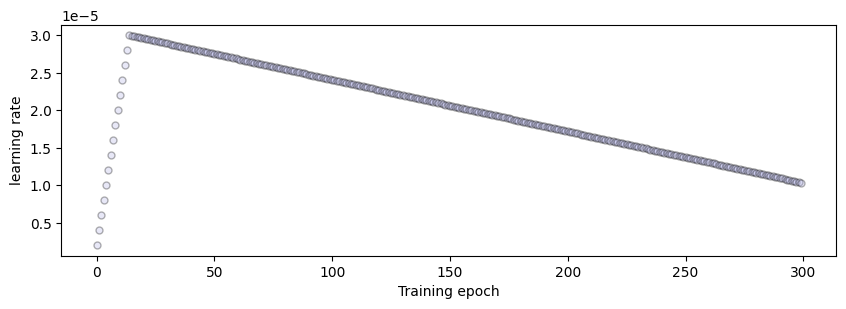

In [38]:
num_samples = 300

# create an optimizer with a dummy "model"
optimizer = torch.optim.AdamW(nn.Linear(10,10).parameters(),lr=3e-5)

#LR SCHEDULER
scheduler  = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(num_samples*.05), # gentle 5% warmup
    num_training_steps=int(num_samples*1.5), # steps set to 150% so the lr stays > 0
)
# quick test to see the lr's
lrs = np.zeros(num_samples)
for i in range(num_samples):
    optimizer.step() # update the optim
    scheduler.step() # run the scheduler
    lrs[i] = scheduler.get_last_lr()[0] # get the actual lr

#plot
plt.figure(figsize=(10,3))
plt.plot(lrs,'ko',markersize=5, markerfacecolor=[.7,.7,.9],alpha=.3)
plt.gca().set(xlabel='Training epoch', ylabel='learning rate')
plt.show()

In [40]:
# Now fr the real optim and loss func
optimizer = torch.optim.AdamW(model.parameters(),lr=1e-5)
loss_fun  = nn.CrossEntropyLoss() # Cross entropy for multi class classification

# IMPORTANTTTTTTTTT: redefine the scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(num_samples*.05), # gentle 5% warmup
    num_training_steps=int(num_samples*1.5), # steps set to 150% so the lr stays > 0
)

## FINE TUNE WITH ADJUSTMENTS

In [43]:
# above cells were soume rough work/
dataset = load_dataset('imdb')

#reduce the size
dataset = DatasetDict({split: dataset[split].select(range(5_000,20_000)) for split in ['train','test']})

In [44]:
# define a token func that processes each data sample
def tokenize_function(one_sample):
    return tokenizer(
        one_sample['text'],
        max_length = 512,
        padding = 'max_length',
        truncation = True)

# apply tokeniation func to dataset (batched for efficiency
tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
})

In [45]:
# remove text pair
tokenized_dataset = tokenized_dataset.remove_columns(['text'])

# change format to pytorch tensors
tokenized_dataset.set_format('torch',columns=['input_ids', 'attention_mask', 'label','token_type_ids'])

# create DataLoaders for training and testing
train_dataloader = DataLoader(tokenized_dataset['train'], shuffle=True, batch_size=16)
test_dataloader = DataLoader(tokenized_dataset['test'], shuffle=True, batch_size=16)

In [ ]:
# For grad clippng we report on  the MLP layer 8 and also the final classifiction layer

In [47]:
train_losses = np.zeros(num_samples)
train_accuracy = np.zeros(num_samples)
test_losses = np.zeros(num_samples)
test_accuracy = np.zeros(num_samples)
norms = np.zeros((num_samples,2))

for sampli in range(num_samples):
    # get a bathc of data
    batch = next(iter(train_dataloader))

    # move to GPU
    tokenz = batch['input_ids'].to(device)
    attn_mask = batch['attention_mask'].to(device)
    labels = batch['label'].to(device)

    # clear the prev grads
    optimizer.zero_grad()

    # fwd pass and get model preds
    logits = model(tokenz, attention_mask = attn_mask)
    predLabels = torch.argmax(logits, dim=1)

    # calculate and store loss+avg accuracy
    loss = loss_fun(logits, labels)
    train_losses[sampli] = loss.item()
    train_accuracy[sampli] = (predLabels == labels).sum().item() / train_dataloader.batch_size

    loss.backward()

    # get two grad norms
    norms[sampli,0] = torch.norm(model.bert.encoder.layer[7].output.dense.weight.grad).item()
    norms[sampli,1] = torch.norm(model.classifier.weight.grad).item()

    # grad clipping (to all of model params) to prevent exploding gradients
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

    # update the weights and lr
    optimizer.step()
    scheduler.step()


    #test the model and report losses every k samples
    if sampli%10 == 0:
        # evaluate using test set
        model.eval()
        with torch.no_grad():
            batch = next(iter(test_dataloader))
            tokenz = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            # fwd pass and get model preds
            logits = model(tokenz, attention_mask = attn_mask)
            predLabels = torch.argmax(logits, dim=1)

            loss = loss_fun(logits, labels)
            test_losses[sampli] = loss.item()
            test_accuracy[sampli] = (predLabels == labels).sum().item() / train_dataloader.batch_size

            print(f'Sample {sampli}/{num_samples}, losses (train/test): {train_losses[sampli]} / {test_losses[sampli]} accuracy {train_accuracy[sampli]} / {test_accuracy[sampli]}')

            #put model back to train mode
            model.train()

Sample 0/300, losses (train/test): 0.7072058320045471 / 0.7653405666351318 accuracy 0.5625 / 0.5
Sample 10/300, losses (train/test): 0.7613164186477661 / 0.6287374496459961 accuracy 0.25 / 0.625
Sample 20/300, losses (train/test): 0.5810495615005493 / 0.6799758672714233 accuracy 0.6875 / 0.4375
Sample 30/300, losses (train/test): 0.5789827108383179 / 0.6446555256843567 accuracy 0.6875 / 0.625
Sample 40/300, losses (train/test): 0.6518594622612 / 0.6653937101364136 accuracy 0.5625 / 0.5
Sample 50/300, losses (train/test): 0.6203258037567139 / 0.6008248329162598 accuracy 0.5625 / 0.75
Sample 60/300, losses (train/test): 0.4340782165527344 / 0.5078279972076416 accuracy 0.875 / 0.875
Sample 70/300, losses (train/test): 0.5267449021339417 / 0.5708200931549072 accuracy 0.875 / 0.6875
Sample 80/300, losses (train/test): 0.2794649004936218 / 0.35127514600753784 accuracy 1.0 / 0.875
Sample 90/300, losses (train/test): 0.5582855343818665 / 0.2464054822921753 accuracy 0.8125 / 0.9375
Sample 100/3

![title](../images/berClipScheduleLossAcc.png)

In [48]:
# Now the learning has become more stable
# the variablity in losses is a bit smaller now
# same with prediction accuracies, more stable now

![title](../images/preclipGrads.png)

In [ ]:
# xaxis is training samples
# y axis shows the grad norms BEFORE CLIPPING for the MLP layer(contraction (which is pretained) and classification layer (not pretrained)
# classifcation layer weights are random

# FOR MLP:
        # has low norm initially, and over trainng it gets shifted more
        # a few training samples where weights matrix had a grad which was pretty large 
           # this could be due to weird examples, like the review text was good, but the classification was 0
            # so model got confused

# FOR CLASSIFICATION layer:
        # early in training, most of the points had grad above 1
           # this means a lot of info that could have used to train the classifier, was lost as part of clipping
        # and eventually it got down to 1 and was stable



In [ ]:
# So question is, is it appropriate to grad clipp these random weights so early in the training???
   # better approach is only do grad clipping after you are done first 10 or 20% of training
